# Insurance Claims Reserving & Runoff Analytics
**Aditya Gujral · Synthetic insurance / Python**

## Summary
At December 31, 2025, the simulation estimates **$138.95 million** outstanding and **$43.12 million** in 2026 existing-claim payments. Calendar-holdout WAPE is **1.88%**. These values reflect a deliberately stable synthetic payment process, not insurer performance.

This notebook is the executed companion to the reusable implementation and exact CSV outputs.

## Context & Methods
Build cumulative paid triangles and fit volume-weighted factors separately for Auto and Liability. Use historical cutoffs to evaluate next-year payment forecasts.

### Key assumptions
All data are generated; all claims finish by development age nine; no reporting delay, case reserves or expenses exist. Outstanding is ultimate minus paid, not pure IBNR. Scenarios are deterministic and do not quantify uncertainty.

[Methodological contract](docs/METHODOLOGY.md) · [CAS chain-ladder tutorial](https://opensourcesoftware.casact.org/chain-ladder) · [CAS tail-factor report](https://www.casact.org/sites/default/files/database/forum_13fforum_02-tail-factors-working-party.pdf)

### 1. Rebuild all inputs and computations
Run from the project directory. The pipeline includes eight unit tests and twelve reconciliation checks. This cell intentionally regenerates project outputs.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from run_project import run
root = Path.cwd()
assert (root / 'run_project.py').exists(), 'Open the notebook in the project directory'
validation = run(root)
print('Validation status:', validation['status'])

     line     paid_usd  ultimate_estimate_usd  outstanding_estimate_usd  synthetic_true_outstanding_usd  reserve_bias_pct
     Auto 168633750.62           205059166.05               36425415.43                      36653694.9             -0.62
Liability 205256746.70           307783157.98              102526411.28                     102393235.6              0.13
Checks passed: 12; total outstanding $138,951,826.71; pooled backtest WAPE 1.88%
Validation status: PASS


## Data
The input CSV grain is claim_id + development_age. Unknown future cells remain missing. Hidden simulated severities and future payments are segregated for evaluation.

In [2]:
metadata = json.loads((root / 'data/generation_metadata.json').read_text())
print('Claims:', metadata['claims'])
print('Observed payment rows:', metadata['observed_payment_rows'])
print('Cutoff:', metadata['valuation_year'])
observed = pd.read_csv(root / 'data/observed_payments.csv')
display(observed.head(6))

Claims: 27540
Observed payment rows: 160650
Cutoff: 2025


claim_id,accident_year,line,development_age,payment_year,payment_cents
1,2014,Auto,0,2014,178549
1,2014,Auto,1,2015,165430
1,2014,Auto,2,2016,84167
1,2014,Auto,3,2017,39497
1,2014,Auto,4,2018,12874
1,2014,Auto,5,2019,25917


## Results
### 2. Outstanding estimate by line
Amounts are undiscounted USD. Liability dominates outstanding because the generator explicitly assigns it larger severity and slower payment timing.

line,paid_usd,ultimate_estimate_usd,outstanding_estimate_usd,synthetic_true_outstanding_usd,reserve_bias_pct
Auto,168633750.62,205059166.05,36425415.43,36653694.9,-0.62
Liability,205256746.70,307783157.98,102526411.28,102393235.6,0.13


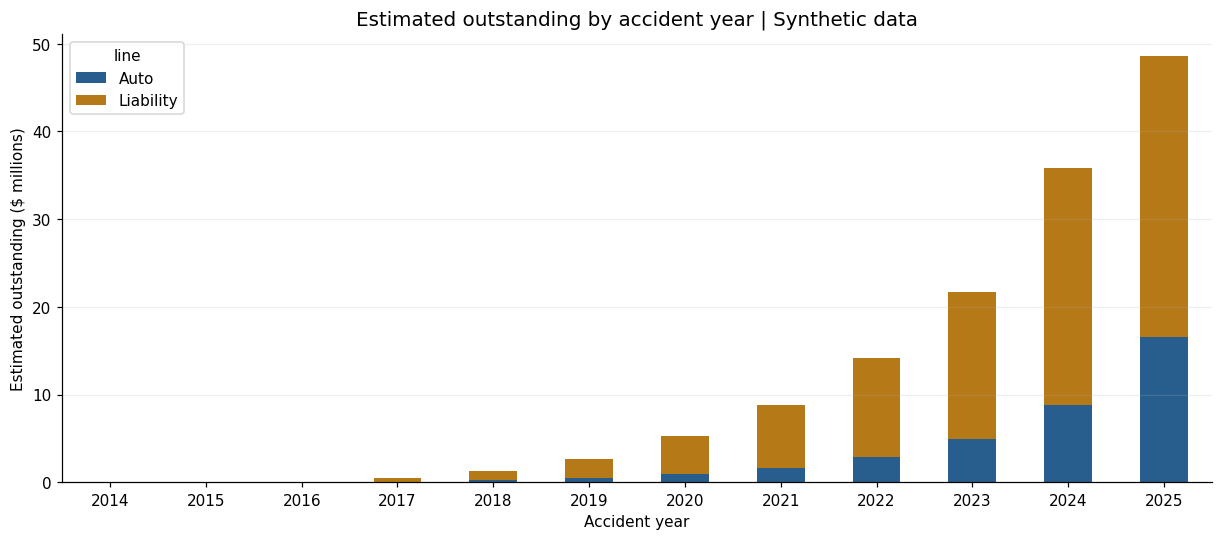

In [3]:
summary = pd.read_csv(root / 'outputs/reserve_summary.csv')
display(summary.round(2))
cohorts = pd.read_csv(root / 'outputs/cohort_estimates.csv')
pivot = cohorts.pivot(index='accident_year', columns='line', values='outstanding_estimate_cents') / 1e8
fig, ax = plt.subplots(figsize=(11, 4.8), layout='constrained')
pivot.plot.bar(stacked=True, ax=ax, color=['#275E8E', '#B57918'], rot=0)
ax.set(title='Estimated outstanding by accident year | Synthetic data', xlabel='Accident year', ylabel='Estimated outstanding ($ millions)')
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=.2)
display(fig)
plt.close(fig)

### 3. Existing-claim runoff
The base forecast excludes new accident years after 2025 and sums to the outstanding estimate. It has no extra-tail cashflow timing.

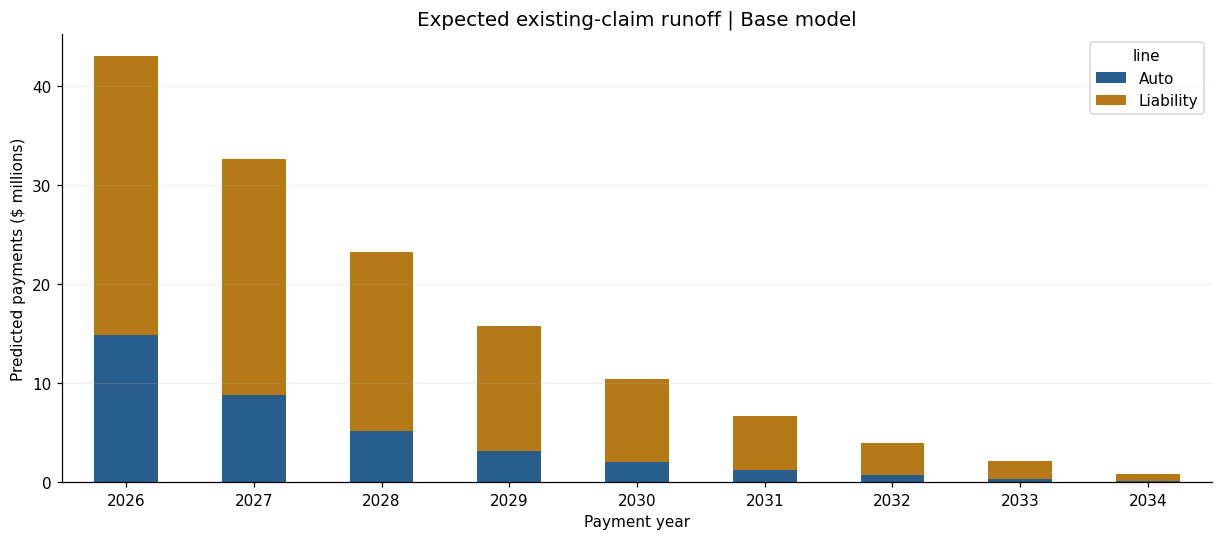

In [4]:
cashflow = pd.read_csv(root / 'outputs/cashflow_summary.csv')
pivot = cashflow.pivot(index='payment_year', columns='line', values='predicted_payment_cents') / 1e8
fig, ax = plt.subplots(figsize=(11, 4.8), layout='constrained')
pivot.plot.bar(stacked=True, ax=ax, color=['#275E8E', '#B57918'], rot=0)
ax.set(title='Expected existing-claim runoff | Base model', xlabel='Payment year', ylabel='Predicted payments ($ millions)')
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=.2)
display(fig)
plt.close(fig)

### 4. Historical calendar holdouts
Fit only payments available at each cutoff. Compare forecast and actual next-year payments for existing accident years. WAPE combines absolute origin-level errors; later observed diagonals are not used during each fit.

In [5]:
backtests = pd.read_csv(root / 'outputs/backtest_summary.csv')
display(backtests.round(3))
detail = pd.read_csv(root / 'outputs/backtest_detail.csv')
wape = 100 * detail.error_cents.abs().sum() / detail.actual_payment_cents.sum()
print(f'Pooled cohort WAPE: {wape:.2f}%')
print('Zero-payment baseline WAPE: 100%')

Pooled cohort WAPE: 1.88%
Zero-payment baseline WAPE: 100%


training_cutoff,evaluation_year,line,evaluated_cohorts,actual_payment_usd,predicted_payment_usd,bias_pct,wape_pct,baseline_zero_payment_wape_pct
2023,2024,Auto,9,12811551.36,12898316.049,0.677,1.302,100.0
2023,2024,Liability,9,24319411.51,24340810.885,0.088,2.426,100.0
2024,2025,Auto,9,13673126.87,13674962.315,0.013,0.901,100.0
2024,2025,Liability,9,26541794.84,26290412.182,-0.947,2.153,100.0


### 5. Sensitivity and evidence
The ±5% cases change each development factor's excess above one. The tail case multiplies ultimate by 1.02. These are not confidence intervals.

In [6]:
scenarios = pd.read_csv(root / 'outputs/sensitivity_scenarios.csv')
display(scenarios.pivot(index='scenario', columns='line', values='outstanding_estimate_usd').round(2))
print(json.dumps(validation['data_checks'], indent=2))
print('Unit tests:', validation['unit_tests'])

{
  "raw_csv_paid_reconciliation": true,
  "raw_csv_payment_count": true,
  "independent_development_factor_reconciliation": true,
  "independent_reserve_product_reconciliation": true,
  "future_cashflow_equals_base_reserve": true,
  "nonnegative_reserve": true,
  "observed_dates_only": true,
  "unknown_future_cells_preserved": true,
  "unique_registry_claims": true,
  "registry_keys_and_attributes_match": true,
  "complete_simulation_cents_reconcile": true,
  "future_holdout_disjoint": true
}
Unit tests: {'run': 8, 'failures': 0, 'errors': 0}


line,Auto,Liability
,40526598.75,108682074.44
,36425415.43,102526411.28
,38690565.94,110540779.47
,34207678.57,94868087.45


## Takeaways
Use separate line-specific patterns, inspect recent Liability accident years, and review the cashflow schedule alongside sensitivity scenarios. The favorable errors are measured only in this simulation.

Real implementation requires reporting and case-reserve data, changing settlement/inflation analysis, empirical tail selection, expense/recovery treatment and actuarial review. The base tail is 1.00 by construction; no probabilistic reserve interval, production adequacy or savings claim is made.

[Exact findings](FINDINGS.md) · [Validation](outputs/validation.json) · [Source generator](src/generate_data.py)